# An Analysis Of Fraud In Transactional Dataset
---

Hamza Ahmed

### N.B.
- To run this notebook, install dependencies with pip install -r requirements.txt

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve

# EDA
---

In [2]:
df = pd.read_csv('task_fraud_rate.csv')
print(f'This data set has {df.shape[0]} Rows and {df.shape[1]} Columns')
df.head(3)

This data set has 10800 Rows and 38 Columns


,networkGrowthFeature15,timeBetweenOrdersFeature15,totalOrderValueFeature1,skuPopularityFeature21,maxOrderValueDeviationFeature,latestOrderPriceFeature15,totalOrderValueFeature25,successfulOrderValueFeature32,successfulOrderValueFeature47,skuCountFeature25,...,skuPopularityFeature35,orderPriceFeature28,orderPriceFeature37,customerId,accountAgeFeature24,anonymousFeature99,oldModelScore,newModelScore,orderTime,customerStatus
0,41.221374,4,3.852355,1.044372e-01,-0.008416,0.756341,3.852355,3.852355,0.963089,1225.0,...,3.441884e-02,0.963089,0.963089,CUSTOMER_ID0,4,1.0,0.440960,0.435500,2021-09-15 21:09:10.669000+00:00,confirmed_fraudster
1,0.005096,70648,14.722513,-9.999999e+06,1.503069,4.247818,7.342932,11.416230,0.000162,121.0,...,-9.999999e+06,3.805410,3.680628,CUSTOMER_ID1,70649,1.0,0.294474,0.266929,2021-09-03 11:26:59.080000+00:00,confirmed_fraudster
2,69.230769,2,1.362888,0.000000e+00,0.033153,0.198355,1.362888,1.362888,0.681444,2015.0,...,0.000000e+00,0.681444,0.681444,CUSTOMER_ID2,2,1.0,0.167179,0.354355,2021-09-16 21:41:28.993000+00:00,confirmed_fraudster


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 38 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   networkGrowthFeature15          10800 non-null  float64
 1   timeBetweenOrdersFeature15      10800 non-null  int64  
 2   totalOrderValueFeature1         10800 non-null  float64
 3   skuPopularityFeature21          10800 non-null  float64
 4   maxOrderValueDeviationFeature   10800 non-null  float64
 5   latestOrderPriceFeature15       10800 non-null  float64
 6   totalOrderValueFeature25        10800 non-null  float64
 7   successfulOrderValueFeature32   10800 non-null  float64
 8   successfulOrderValueFeature47   10800 non-null  float64
 9   skuCountFeature25               10800 non-null  float64
 10  orderNumberFeature42            10800 non-null  float64
 11  skueValueFeature3               10800 non-null  float64
 12  marketCountry                   10800 non-n

No actual null values are present

In [4]:
df.describe()

,networkGrowthFeature15,timeBetweenOrdersFeature15,totalOrderValueFeature1,skuPopularityFeature21,maxOrderValueDeviationFeature,latestOrderPriceFeature15,totalOrderValueFeature25,successfulOrderValueFeature32,successfulOrderValueFeature47,skuCountFeature25,...,orderValueFeature73,accountAgeFeature12,lastestOrderValueFeature81,skuPopularityFeature35,orderPriceFeature28,orderPriceFeature37,accountAgeFeature24,anonymousFeature99,oldModelScore,newModelScore
count,10800.000000,1.080000e+04,10800.000000,1.080000e+04,1.080000e+04,1.080000e+04,10800.000000,1.080000e+04,1.080000e+04,1.080000e+04,...,1.080000e+04,1.080000e+04,10800.000000,1.080000e+04,1.080000e+04,10800.000000,1.080000e+04,1.080000e+04,10800.000000,10800.000000
mean,1108.418426,4.706893e+05,32.759487,-6.692592e+06,-2.870283e+04,-6.203567e+04,6.635615,-1.942171e+04,-1.944414e+04,-6.146703e+04,...,-7.638887e+05,4.706905e+05,1.635970,-6.692592e+06,-1.944286e+04,1.596993,4.706905e+05,-3.726851e+06,0.085002,0.088036
std,3221.630184,5.792127e+05,142.167742,4.705016e+06,5.350137e+05,7.852254e+05,47.298215,4.405510e+05,4.405500e+05,7.852711e+05,...,2.656316e+06,5.792124e+05,1.948460,4.705016e+06,4.405501e+05,1.579886,5.792124e+05,4.835417e+06,0.073905,0.097330
min,0.000152,0.000000e+00,0.000000,-9.999999e+06,-9.999999e+06,-9.999999e+06,0.000000,-9.999999e+06,-9.999999e+06,-9.999999e+06,...,-9.999999e+06,0.000000e+00,0.000000,-9.999999e+06,-9.999999e+06,0.000000,0.000000e+00,-9.999999e+06,0.000000,0.000000
25%,0.000708,7.000000e+00,1.365387,-9.999999e+06,-2.704832e-02,3.852316e-01,0.626963,1.234262e+00,8.482067e-06,2.000000e+01,...,3.544677e-06,8.000000e+00,0.479650,-9.999999e+06,6.547966e-01,0.664316,8.000000e+00,-9.999999e+06,0.043333,0.031629
50%,0.002640,1.863100e+05,3.578855,-9.999999e+06,4.615358e-01,8.589823e-01,1.529466,3.224471e+00,6.334010e-05,1.170000e+02,...,2.119345e-05,1.863105e+05,1.062500,-9.999999e+06,1.209201e+00,1.217274,1.863105e+05,1.000000e+00,0.080833,0.077864
75%,44.490358,8.123628e+05,10.502430,0.000000e+00,1.151578e+00,1.935198e+00,3.315451,8.876623e+00,1.526277e-01,5.930000e+02,...,8.037110e-03,8.123628e+05,2.303583,0.000000e+00,2.073138e+00,2.091920,8.123628e+05,1.000000e+00,0.120469,0.125241
max,14400.000000,2.162882e+06,2577.046753,1.216840e+00,1.999027e+01,3.705455e+01,1773.042105,2.342355e+03,3.735175e+01,7.792000e+03,...,1.156932e+01,2.162883e+06,45.693767,7.307627e-01,3.828401e+01,38.284007,2.162883e+06,1.000000e+00,0.658793,0.995500


In [5]:
# Check for duplicate column names 
df.columns.duplicated().sum()

np.int64(0)

### Overall Fraud Rate In Dataset

In [3]:
overall_fraud_rate = df['customerStatus'].value_counts(normalize=True)['confirmed_fraudster']
print(f'Overall Fraud rate in dataset = {overall_fraud_rate * 100:.2f}%')

Overall Fraud rate in dataset = 7.41%


In [4]:
# Isolate numeric and categorical columns
num_cols = df.select_dtypes(exclude=['object', 'string']).columns.to_list()
cat_cols = df.select_dtypes(include=['object', 'string']).columns.to_list()

In [8]:
print(f'Numeric Columns in Dataset: {num_cols}')
print(f'\nCategorical Columns in Dataset: {cat_cols}')

Numeric Columns in Dataset: ['networkGrowthFeature15', 'timeBetweenOrdersFeature15', 'totalOrderValueFeature1', 'skuPopularityFeature21', 'maxOrderValueDeviationFeature', 'latestOrderPriceFeature15', 'totalOrderValueFeature25', 'successfulOrderValueFeature32', 'successfulOrderValueFeature47', 'skuCountFeature25', 'orderNumberFeature42', 'skueValueFeature3', 'lastestOrderVolume5', 'maxOrderValueDeviation', 'paymentMethodDistanceFeature12', 'networkGeneralSizeFeature25', 'successfulOrderCountFeature12', 'orderValueFeature56', 'networLocalGrowthFeature35', 'successfulOrderValueFeature61', 'skuPopularityFeature24', 'networkLocalSizeFeature40', 'emailFeature15', 'orderValueFeature73', 'accountAgeFeature12', 'lastestOrderValueFeature81', 'skuPopularityFeature35', 'orderPriceFeature28', 'orderPriceFeature37', 'accountAgeFeature24', 'anonymousFeature99', 'oldModelScore', 'newModelScore']

Categorical Columns in Dataset: ['marketCountry', 'isEWallet', 'customerId', 'orderTime', 'customerStatus'

**orderTime** should be in datetime not string format

In [5]:
# Change data type of orderTime from str to date_time
df['orderTime'] = pd.to_datetime(df['orderTime'], format='ISO8601')

In [6]:
# update cat_cols:
cat_cols = df.select_dtypes(include=['object', 'string']).columns.to_list()
cat_cols

['marketCountry', 'isEWallet', 'customerId', 'customerStatus']

## Initial Evaluation

1. The dataset has 10,800 rows and 38 columns
2. Column names are stored with a prefix of "Feature" followed by a number, although no column names repeat, some features are repeated with different numbers e.g. successfulOrderValueFeature32 successfulOrderValueFeature47. The values in the features are different suggesting a transformation of some sort (feature engineering)
3. Although there no actual Null values present, there are missing values that have been flagged with -9,999,999 in the numeric columns this is an integer value, and in categorical columns this is a string value. - These need to be treated as `missing values` as they effect the statistics like mean, std to be much more extreme
4. The % of overall fraud rate in the dataset is calculated to be **7.4%**

## Investigating Sentinel Values

In [7]:
# Produce a Dataframe of sentinal counts with features with ranked with the highest to lowest missing values
sentinel_counts = (df[num_cols] ==  -9999999).sum()
sentinel_counts = sentinel_counts[sentinel_counts > 0].sort_values(ascending=False)
sentinel_counts_df = sentinel_counts.reset_index()
sentinel_counts_df.columns = ['feature', 'count']
sentinel_counts_df['pct_total'] = (sentinel_counts_df['count'] / len(df)) * 100

In [12]:
sentinel_counts_df

,feature,count,pct_total
0,skuPopularityFeature21,7228,66.925926
1,skuPopularityFeature24,7228,66.925926
2,skuPopularityFeature35,7228,66.925926
3,anonymousFeature99,4025,37.268519
4,paymentMethodDistanceFeature12,3069,28.416667
5,orderNumberFeature42,825,7.638889
6,orderValueFeature73,825,7.638889
7,skuCountFeature25,67,0.620370
8,skueValueFeature3,67,0.620370
9,lastestOrderVolume5,67,0.620370


Of the numeric features, there are 18 features in total with missing values, the feature with the highest amount of missing value is skuPopularity(21,23, 35) with ~67% missing data.

In [8]:
# Categorical features with missing values
cat_sentinel_sums = {}

for cat in cat_cols:
    sum = df[cat].str.contains('-9999999').sum()
    if sum > 0:
        cat_sentinel_sums[cat] = sum

for k, v in cat_sentinel_sums.items():
    print(f'Category {k} has {v} number of missing values')

Category isEWallet has 10201 number of missing values


In [14]:
df['isEWallet'].value_counts()

isEWallet
-9999999     10201
googlepay      599
Name: count, dtype: int64

The category column isEWallet 94.5% missing data, these can be categorised as standard payment or non Google payments

### Fraud Rate By Dimension : isEWallet, marketCountry, Time

In [10]:
# Create a binary flag in the dataset for is fraud 
df['is_fraud'] = df['customerStatus'].apply(lambda x : 1 if x == 'confirmed_fraudster' else 0)

In [11]:
# calculate the porportion of fraud in isEWallet transactions : 
porportion_fraud_in_eWallet = df.groupby('isEWallet')['is_fraud'].mean() * 100
print(porportion_fraud_in_eWallet)

isEWallet
-9999999      4.195667
googlepay    62.103506
Name: is_fraud, dtype: float64


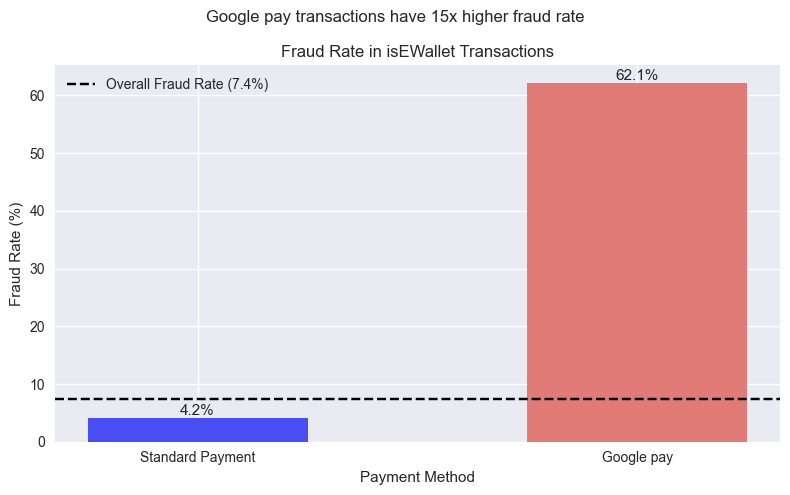

In [17]:
""" Bar Chart showcasing Fraud Rates in isEWallet Transactions """

fig, ax = plt.subplots(figsize=(8,5))

labels = ['Standard Payment', 'Google pay']
values = porportion_fraud_in_eWallet.values

bars = ax.bar(labels, values, color=['#494EF2', '#E17B77'], width=0.5)
ax.axhline(y=(overall_fraud_rate*100), color='black', linestyle='--', label='Overall Fraud Rate (7.4%)')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center', fontsize=11
    )


fig.suptitle("Google pay transactions have 15x higher fraud rate")
ax.set_title('Fraud Rate in isEWallet Transactions')
ax.set_ylabel('Fraud Rate (%)')
ax.set_xlabel('Payment Method')
ax.legend()
plt.tight_layout()
plt.show()


**62% of Google pay transactions are fraudulent**
- There are 599 Google pay transactions * 62% = 372 fraudsters out of total 800 in the entire dataset
- Nearly 1/2 of the transactions in the dataset are a result from Google pay

In [12]:
# Calculate the proportion of fraud in in marketCountry
porportion_fraud_in_marketCountry = df.groupby('marketCountry')['is_fraud'].mean() * 100
print(porportion_fraud_in_marketCountry.sort_values(ascending=False))

marketCountry
MARKET_ID45     100.0
MARKET_ID42     100.0
MARKET_ID64     100.0
MARKET_ID37     100.0
MARKET_ID25      50.0
                ...  
MARKET_ID110      0.0
MARKET_ID109      0.0
MARKET_ID108      0.0
MARKET_ID107      0.0
MARKET_ID99       0.0
Name: is_fraud, Length: 135, dtype: float64


In [13]:
# Isolate market_countries with atleast 50 orders
market_counts = df.groupby('marketCountry').size().sort_values(ascending=False)
valid_markets = market_counts[market_counts >= 50].index
df_filtered_for_valid_markets = df[df['marketCountry'].isin(valid_markets)]
porportion_fraud_in_valid_markets = df_filtered_for_valid_markets.groupby('marketCountry')['is_fraud'].mean() * 100

In [48]:
# Porportion of orders from Market_ID24 
orders_from_market_id24 = market_counts.loc['MARKET_ID24']
porportion_of_orders_from_id24 = (orders_from_market_id24 / market_counts.sum()) * 100
print(f"Percentage of Orders from Market ID 24 : {porportion_of_orders_from_id24}")

Percentage of Orders from Market ID 24 : 0.5740740740740741


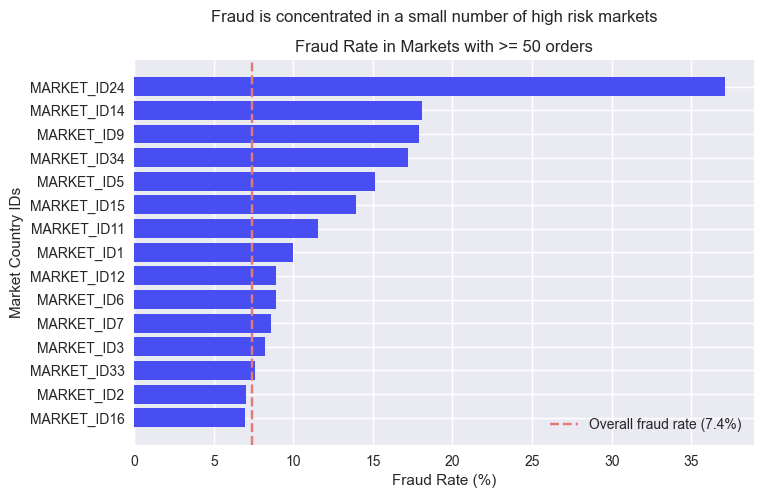

In [20]:
""" Plotting Horizontal Bar Chart for MarketCountry  Transactions """
fig, ax = plt.subplots(figsize=(8,5))

top15 = porportion_fraud_in_valid_markets.sort_values(ascending=False).head(15)
top15 = top15.sort_values(ascending=True)

labels = top15.index
values = top15.values

ax.barh(labels, values, color='#494EF2')
ax.axvline(x=7.4, color='#E17B77', linestyle='--', label='Overall fraud rate (7.4%)')

fig.suptitle("Fraud is concentrated in a small number of high risk markets")
ax.set_title('Fraud Rate in Markets with >= 50 orders')
ax.set_ylabel('Market Country IDs')
ax.set_xlabel('Fraud Rate (%)')
ax.legend()
plt.show()

Market Country with ID 24 shows the highest rate of fraud at ~37% with other concerning markets being:
MARKET_ID14    
MARKET_ID9    
MARKET_ID34   
MARKET_ID5     
MARKET_ID15    
MARKET_ID11    
MARKET_ID1     
MARKET_ID12     
MARKET_ID6     
MARKET_ID7      
MARKET_ID3          

In [21]:
# Time Dimension : Looking at weekly transactions and fraud rate per week
df['weekOfTransaction'] = df['orderTime'].dt.to_period('W')
fraud_rate_weekly = df.groupby('weekOfTransaction')['is_fraud'].mean() * 100

/var/folders/ky/j35rpnmx4pnf9ddhtmnv2hbw0000gn/T/ipykernel_59502/2207758860.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['weekOfTransaction'] = df['orderTime'].dt.to_period('W')


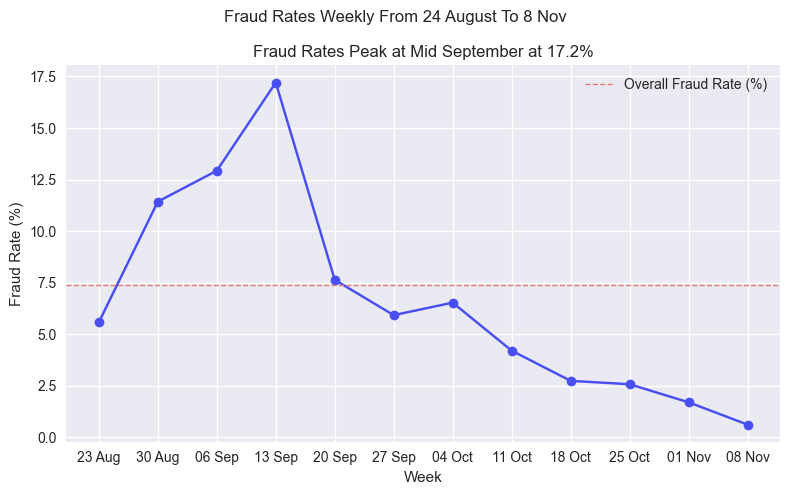

In [22]:
""" Line plot for Fraud Rates By Week """

fig, ax = plt.subplots(figsize=(8,5))
# Gets the format of weekly Transaction is day month (abbreviated)
labels = [
    f"{p.start_time.strftime('%d %b')}" for p in fraud_rate_weekly.index
]
values = fraud_rate_weekly.values

ax.plot(labels, values, marker = 'o', color='#494EF2')
ax.axhline(y=7.4, color='#E17B77', linestyle='--', linewidth=1, label='Overall Fraud Rate (%)')

fig.suptitle("Fraud Rates Weekly From 24 August To 8 Nov")
ax.set_title("Fraud Rates Peak at Mid September at 17.2%")
ax.set_xlabel('Week')
ax.set_ylabel('Fraud Rate (%)')
ax.legend()

plt.tight_layout()
plt.show()

Concerning increase in Fraud, surged through september, peaked at 17.2% in mid September, more than double the overall rate. Then there was a steady decline. Hard to discern if this is a patterns as only 12 weeks of data present, so difficult to correlate with "September has the highest Fraud rate"

# Feature Importance
---

The core question is **Which features are most useful for predicting whether an order is fradulent?**

One of the most common methods for evaluating feature importance is training a simple Random Forest algorithm on the data. 


Here, I will be using two approaches to gather which features have the highest influence in model results from the mdoel: 

1. Gini Importance from Random Forest
2. Permutation Feature



### The Approach

**Prepare Dataset :** 

- Remove model scores, is_fraud, customerStatus, orderTime and customerId from dataset
(customerId has no predictive featureset, leaving it in may result in overfitted models)
- Replace sentinel values with NaN

**Transform Features :**

1. OHE Categorical features
2. Impute categorical features with most frequent, and numerical features with median values 

**Feature Importance:**
1. Train Random Forest Model
- Extract Gini importance scores
- Permute features and get model scores

In [23]:
# Drop new and old model scores, monthOfTransaction and is_fraud (avoids Data Leakege)
X = df.drop(['oldModelScore', 'newModelScore', 'is_fraud', 'customerStatus', 'orderTime', 'customerId'], axis=1)
# Convert period column to ordinal
X['weekOfTransaction'] = X['weekOfTransaction'].apply(lambda x : x.ordinal)
# Get the target variable (customerStatus)
y = df['customerStatus']

In [24]:
print(X.shape)
print(y.shape)

(10800, 34)
(10800,)


In [25]:
# Extract feature dataset numeric columns and categorical columns
# Numeric columns
feature_num_cols = X.select_dtypes(exclude=(['object', 'string'])).columns.to_list()
# Categorical columns
feature_cat_cols = X.select_dtypes(include=(['object', 'string'])).columns.to_list()

In [26]:
print(feature_num_cols)
print(feature_cat_cols)

['networkGrowthFeature15', 'timeBetweenOrdersFeature15', 'totalOrderValueFeature1', 'skuPopularityFeature21', 'maxOrderValueDeviationFeature', 'latestOrderPriceFeature15', 'totalOrderValueFeature25', 'successfulOrderValueFeature32', 'successfulOrderValueFeature47', 'skuCountFeature25', 'orderNumberFeature42', 'skueValueFeature3', 'lastestOrderVolume5', 'maxOrderValueDeviation', 'paymentMethodDistanceFeature12', 'networkGeneralSizeFeature25', 'successfulOrderCountFeature12', 'orderValueFeature56', 'networLocalGrowthFeature35', 'successfulOrderValueFeature61', 'skuPopularityFeature24', 'networkLocalSizeFeature40', 'emailFeature15', 'orderValueFeature73', 'accountAgeFeature12', 'lastestOrderValueFeature81', 'skuPopularityFeature35', 'orderPriceFeature28', 'orderPriceFeature37', 'accountAgeFeature24', 'anonymousFeature99', 'weekOfTransaction']
['marketCountry', 'isEWallet']


In [27]:
# Replace numeric sentinel values with nan
X = X.replace(-9999999, np.nan)

# Replace string sentinel values with nan 
for cat_col in feature_cat_cols:
    X[cat_col] = X[cat_col].replace('-9999999', np.nan)

In [28]:
# Split the data into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8640, 34)
(2160, 34)
(8640,)
(2160,)


In [30]:
# Pipeline for Data Transformation
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])
cat_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehotencoding', OneHotEncoder(handle_unknown='ignore'))
        ]
)

transformer = ColumnTransformer(transformers=[
    ('num_pipeline', num_pipeline, feature_num_cols),
    ('cat_pipeline', cat_pipeline, feature_cat_cols)
])

X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

In [31]:
feature_names = transformer.get_feature_names_out()
print(len(feature_names))

159


In [32]:
# Train a RandomForestClassifier model
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
model.fit(X_train_transformed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Gini Importance Scores

In [33]:
# Extract the top 15 features and scores 
importance_scores = model.feature_importances_
importance_df = pd.DataFrame({
    'feature' : feature_names,
    'importance' : importance_scores
}).sort_values('importance', ascending=False).head(15)
# strip prefixes from ohe
importance_df['feature'] = importance_df['feature'].str.replace('num_pipeline__', '').str.replace('cat_pipeline__', '')

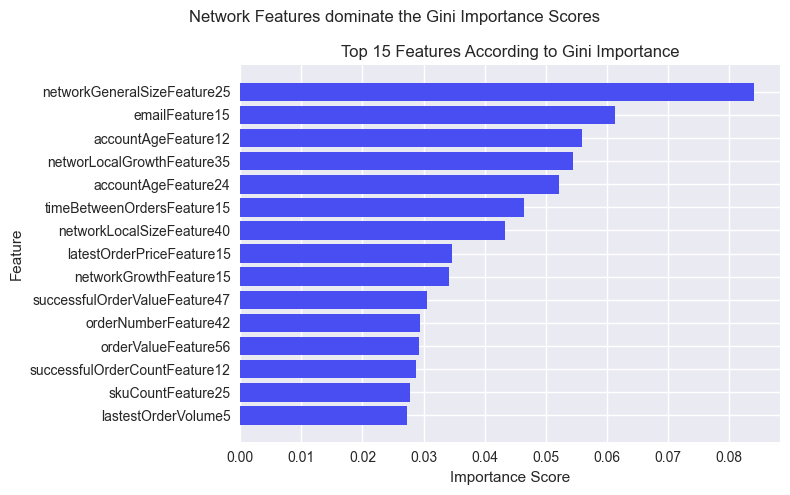

In [34]:
plot_df = importance_df.sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(plot_df['feature'], plot_df['importance'], color='#494EF2')

fig.suptitle('Network Features dominate the Gini Importance Scores')
ax.set_title('Top 15 Features According to Gini Importance')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

### Evaluation of Gini Importance Scores

- Network features dominate the top:
    - `networkGeneralSizeFeature25` rank 1
    - `networLocalGrowthFeature35` rank 4
    - `networkLocalSizeFeature40` rank 7
    - `networkGrowthFeature15` rank 9

Fraudsters likely cluster within networks, making network-based features strong early splits in the trees.

- `accountAgeFeature12` newer or older accounts correlate with fraud
- `emailFeature15` email-based signals (disposable or new emails) are known fraud indicators

**Note on isEWallet:** Despite being a strong fraud signal (62% fraud rate for GooglePay), isEWallet does not appear in the top 15. This is because 94.5% missing data caused imputation to dilute its signal significantly.

## Permutation Importance

Permutation importance measures how much model performance (ROC-AUC) drops when a feature's values are randomly shuffled; breaking its relationship with the target. If shuffling a feature causes a large drop in performance, that feature is genuinely important.

**Use of ROC-AUC rather than Accuracy**

ROC-AUC is used as the scoring metric rather than accuracy. With a 7.4% fraud rate, a model that predicts 'genuine' for every transaction achieves 92.6% accuracy, hence accuracy would be misleading here

In [35]:


y_binary = (y_test == 'confirmed_fraudster').astype(int)

# Custom scorer to ensure I use confirmed_fraudster probability (index 0)
# sklearn sorts classes alphabetically: confirmed_fraudster=0, genuine_customer=1
def fraud_roc_auc(estimator, X, y):
    proba = estimator.predict_proba(X)[:, 0]
    score = roc_auc_score(y, proba)
    return score

perm_result = permutation_importance(
    model, X_test_transformed.toarray(), y_binary,
    scoring=fraud_roc_auc, n_repeats=10, random_state=42
)

perm_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': perm_result.importances_mean
}).sort_values('importance', ascending=False).head(15)

perm_df['feature'] = (perm_df['feature'].str.replace('num_pipeline__', '', regex=False).str.replace('cat_pipeline__', '', regex=False))

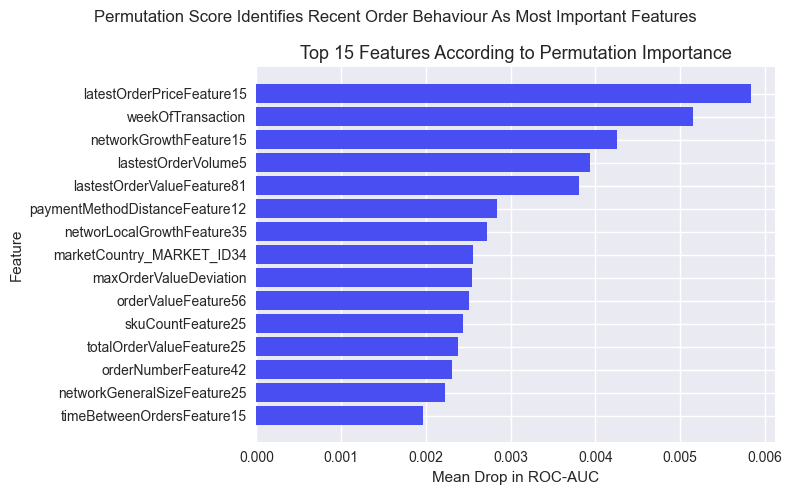

In [36]:
plot_df = perm_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_df['feature'], plot_df['importance'], color='#494EF2')
fig.suptitle("Permutation Score Identifies Recent Order Behaviour As Most Important Features")
ax.set_title('Top 15 Features According to Permutation Importance', fontsize=13)
ax.set_xlabel('Mean Drop in ROC-AUC')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

**Key finding:** 

Permutation importance identifies recent order behaviour as the stronger signal — `latestOrderPriceFeature15`, `networkGrowthFeature15`, and `latestOrderValueFeature81`

The disagreement between the two methods is itself informative: Gini overstates correlated network features near tree roots; permutation more honestly tests what the model actually relies on.

**Combined story:** 

Fraudsters are most distinguishable by their recent order behaviour and network signals. Features related to these should be prioritised in future model training.

# Analysis of Rule Based Interventions
---


Rules are a critical layer in any fraud system, they handle **known, stable patterns instantly** and complement the ML model (which handles subtle, evolving ones). A good rule is:
- **Simple to explain** to a client fraud manager
- **Evaluated honestly** precision, recall, and block rate all matter
- **Framed as a trade-off** catching more fraud always costs some legitimate orders


## The Approach

Every rule is just a boolean mask i.e. a seires of True/False where True means "this order gets blocked" and False means "this order is allowed". Once we have this mask, I evaluate the same 5 metrics: 

1. **Blocked**: How many orderes does this rule block in total?
2. **Fraud Caught**: Of these blocked, how many were actually fraud (rules_mask, & is_fraud)
3. **Legit Blocked**: Of those blocked, how many were genuine customers (rule_mas & ~is_fraud)
4. **Precision** - fraud_caught / blocked (what is the % of blocks that are correct)
5. **Recall** - fraud_caught / total_fraud (what is % of all fraud that is caught)
6. **Block Rate**- blocked / total (what is the % of blocked in all transactions)


In [57]:
def evaluate_rule(rule_mask, label_series, rule_name):
    
    """ 
    Evaluate a fraud rule given a boolean mask of which orderes it blocks. 
    
    rule_mask : boolean Series - True = this order is blocked by the rule
    
    lable_series : Seried of confirmed_fraudster / genuine customer
    rule name " String label for output row
    
    """
    
    is_fraud = (label_series == 'confirmed_fraudster')
    
    # total number of rows in dataset
    total = len(label_series)
    # Number of Fraud in the dataset 
    total_fraud = is_fraud.sum()
    # If we block all transactions associated with this rule, how many transactions are blocked?
    blocked = rule_mask.sum()
    # How many blocked transactions were actually fraud
    fraud_caught = (rule_mask & is_fraud).sum()
    # Of the transactions blocked, how many were legitmate 
    legit_blocked = (rule_mask & ~is_fraud).sum()
    # Percision : Porportion of blocks that were correct
    percision = (fraud_caught / blocked) * 100 if blocked > 0 else 0
    # Recall : Porportion of fraud caught in total fraud in dataset
    recall = (fraud_caught / total_fraud) * 100 if total_fraud > 0 else 0
    # % of transactions blocked by this rule
    block_rate = (blocked / total * 100) if total > 0 else 0
    return {
        "Rule" : rule_name,
        "Blocked" : int(blocked),
        "Fraud Caught" : int(fraud_caught),
        "Legitame Blocked" : int(legit_blocked),
        "Percision" : round(float(percision), 2),
        "Recall" : round(float(recall), 2),
        "Block Rate" : round(float(block_rate), 2)
    }

## Rule 1: Block Google pay transactions

In [58]:
rule1_mask = df['isEWallet'] == 'googlepay'
rule1 = evaluate_rule(rule1_mask, df['customerStatus'], 'Block Googlepay Transactions')
rule1

{'Rule': 'Block Googlepay Transactions',
 'Blocked': 599,
 'Fraud Caught': 372,
 'Legitame Blocked': 227,
 'Percision': 62.1,
 'Recall': 46.5,
 'Block Rate': 5.55}

### Evaluation

**Good Rule**

If we block all googlepay transactions, we catch 372 of 800 fraudsters (46.5% recall) with 62.1% precision and we only disrupt 5.5% of all orders. High precision, meaningful recall and a low disruption to overall order flow

## Rule 2: Block transactions from risky markets

Here I evaluate the risk level of a market via its fraud rate, 
- A bin of low to high risk markets contain all markets with a fraud rate of greater than or equal to 10
- A bin of medium to high risk markets contain all markets with a fraud rate of greater than or equal to 15
- High risk markets are those with a fraud rate > 30

The thresholds for these bins were chosen from the fraud rates in valid markets in the Fraud By Dimension section

In [39]:
permissive = porportion_fraud_in_valid_markets[porportion_fraud_in_valid_markets > 10].index.to_list()
permissive_mask = df['marketCountry'].isin(permissive)
permissive_rule = evaluate_rule(permissive_mask, df['customerStatus'], 'Block Low - High Risk Markets')
permissive_rule

{'Rule': 'Block Low - High Risk Markets',
 'Blocked': 1769,
 'Fraud Caught': 286,
 'Legitame Blocked': 1483,
 'Percision': 16.17,
 'Recall': 35.75,
 'Block Rate': 16.38}

In [40]:
moderate = porportion_fraud_in_valid_markets[porportion_fraud_in_valid_markets > 15].index.to_list()
moderate_mask = df['marketCountry'].isin(moderate)
moderate_rule = evaluate_rule(moderate_mask, df['customerStatus'], 'Block Low - High Risk Markets')
moderate_rule

{'Rule': 'Block Low - High Risk Markets',
 'Blocked': 1550,
 'Fraud Caught': 258,
 'Legitame Blocked': 1292,
 'Percision': 16.65,
 'Recall': 32.25,
 'Block Rate': 14.35}

In [41]:
strict = porportion_fraud_in_valid_markets[porportion_fraud_in_valid_markets > 30].index.to_list()
strict_mask = df['marketCountry'].isin(strict)
strict_rule = evaluate_rule(strict_mask, df['customerStatus'], 'Block Low - High Risk Markets')
strict_rule

{'Rule': 'Block Low - High Risk Markets',
 'Blocked': 62,
 'Fraud Caught': 23,
 'Legitame Blocked': 39,
 'Percision': 37.1,
 'Recall': 2.88,
 'Block Rate': 0.57}

### Evaluation 

**Bad Rule**

**Permissive Threshold**

- Setting a permissive threshold, blocks 1769 transactions, which is 16.38% of all transactions blocked. Of these 286 were fraudulant and 1483 were legitimate, giving a low precision score of only 16.17% and a recall (ratio of fraud caught over all fraud activities in the entirie dataset)
- Based on this, advice would be to not apply this rule as the number of legitimate transactions blocked is too high and the return of 16.17% is not good enough and will negatively impact legit customers from this country

**Moderate Threshold**

- Setting a moderate threshold, blocks 1550 of the transactions which represents 14.35% of all transactions. Of these 258 were fraudulant, and 1292 were legitimate
- Again like high threshold, too many legitiamte transactions are blocked with a percision score not much greater than the high threshold of 16.65%, therefore this rule should not be applied


**Strict Threshold** 

- Setting a threshold value of only blocking transactions where fraudlent activitiy was greater than 30, means we  block 62 transactions which is only 0.57% of the transactions blocked overall
- Although this number seems low, the number of legitmate transactions blocked (39) is still more than the fraudulant ones (23). Percision is higher at 37.1% meaning that 63% of legititmate customer transactions will be blocked
- This information must be taken with teh fact that the data that is preasent spands only 4 months, and only one country ID24 meets the criteria of having fraud rater greater than 30, given more time more transactions may occure from this country. It would be premature to block all transactions from this country and there may be more legitimate transactions in the future. 
- Advice is to wait until more data is preasent and if the % of fraud transactions does not decerease then block transactions from this country, with this rule

## Rule 3: Model Score Threshold

Modesl scores outs put a value between 0 and 1 ; a probability of how likely the model thinks given the data the transaction is fraudlent. We can set a threshold value to block transactions over a certian threshold. 

Here I have evaluated three threshold values : 0.3, 0.5 and 0.7 with the aliases : 0.3 (permissive) threshold means that the model thinks there is a 30% chance of these transactions being fraudulant so in essence we are blocking more transactions compared to a more strict threshold (0.7) where transactions are only blocked if there is atleast a 70% that the transaction is fradulent, 0.5 is moderate as it is in the middle

In [42]:
df[['newModelScore', 'oldModelScore']].describe()

,newModelScore,oldModelScore
count,10800.000000,10800.000000
mean,0.088036,0.085002
std,0.097330,0.073905
min,0.000000,0.000000
25%,0.031629,0.043333
50%,0.077864,0.080833
75%,0.125241,0.120469
max,0.995500,0.658793


In [59]:
rule3_permissive_mask = df['newModelScore'] >= 0.3
rule3_permissive = evaluate_rule(rule3_permissive_mask, df['customerStatus'], 'New model score threshold at 0.3')
rule3_permissive

{'Rule': 'New model score threshold at 0.3',
 'Blocked': 346,
 'Fraud Caught': 246,
 'Legitame Blocked': 100,
 'Percision': 71.1,
 'Recall': 30.75,
 'Block Rate': 3.2}

In [44]:
rule3_moderate_mask = df['newModelScore'] >= 0.5
rule3_moderate = evaluate_rule(rule3_moderate_mask, df['customerStatus'], "Moderate New Model Score")
rule3_moderate

{'Rule': 'Moderate New Model Score',
 'Blocked': 65,
 'Fraud Caught': 55,
 'Legitame Blocked': 10,
 'Percision': 84.62,
 'Recall': 6.88,
 'Block Rate': 0.6}

In [107]:
rule3_strict_mask = df['newModelScore'] >= 0.7
rule3_strict = evaluate_rule(rule3_strict_mask, df['customerStatus'], "Strict New Model Score")
rule3_strict

{'Rule': 'Strict New Model Score',
 'Blocked': 55,
 'Fraud Caught': 47,
 'Legitame Blocked': 8,
 'Percision': 85.45,
 'Recall': 5.88,
 'Block Rate': 0.51}

### Evaluation

**Good Rule**

**Permissive Rule** 

- This rule blocks 346 transactions, which is a block rate of 3.2%. Of these blocked, 246 were confirmed fraudsters, which gives a precision of 71.1%, we caught 30.75% of all fraud in the dataset (recall) and blocked 100 legitmate transactions. 
- Overall this is a strong rule to apply to the dataset. 

**Moderate Rule**

- This rule blocks 65 transactions which is a block rate of 0.6%. Of these blocked, 55 were confirmed fraudsters, this means that only 10 legitimate customers were blocked, a percision score of 84.6%. However, we are cathing fewer fraud in the overall dataset (recall of 6.88%)

**Strict Rule**

- This rule blocks 55 transaction in total, of which 47 were fradulant, giving a good precision score of 85.45%, however this rule only cathes 5.88% of all fraudulent activity in the dataset. 
- Number of legitimate customers blocked is 8 only two less than a moderate score


Looking at the results there was a huge gap in 0.3 and 0.5 compared to 0.5 and 0.7 in ROI. Therefore, I investigated further and evaluted threshold values at 0.4 and 0.45, this showed that : 

- At **0.4** :
    - We block 250 transactions in total, (a block rate of 2.31%). Of these 182 were fraud, a high marginally better percision than 0.3, with a substantial loss in recall (overall fraud caught)
- At **0.45** :
    - We block we block 87 transactions, with a substanial gain in percision (80.46%) compared to 71.1% (at 0.3 threshold). 
    - We are blocking less legitimate transactions but a substantual loss in recall 8.75%

Between 0.4 and 0.45:
  - 0.4 → Recall 22.75%, Blocked 250
  - 0.45 → Recall 8.75%, Blocked 87

That's a massive cliff, dropping from 22% to 8% recall in just a 0.05 threshold move. That means a large cluster of fraudsters score between 0.40 and 0.45.

In [71]:

is_fraud = (df['customerStatus'] == 'confirmed_fraudster')

threshold_values = [round(t, 1) for t in np.arange(0.1, 1, 0.1)]
precision_scores = []

for value in threshold_values:
    newModelScore = df['newModelScore'] >= value
    fraud_caught = (is_fraud & newModelScore).sum()
    blocked = newModelScore.sum()
    precision = (fraud_caught / blocked) if blocked > 0 else 0
    precision_scores.append(precision)

print(precision_scores)
    
    
    

    
    
    

[np.float64(0.20687593423019432), np.float64(0.6853448275862069), np.float64(0.7109826589595376), np.float64(0.728), np.float64(0.8461538461538461), np.float64(0.8571428571428571), np.float64(0.8545454545454545), np.float64(0.8695652173913043), np.float64(0.7647058823529411)]


In [94]:
def get_precision_and_recall_scores(y_true : pd.Series, y_scores : pd.Series, threshold_values=None) -> pd.DataFrame:
    
    if threshold_values is None:
        threshold_values = [round(t, 1) for t in np.arange(0.1, 1.0, 0.1)]
    
    confirmed_fraud = y_true.sum()
    results = []
    
    for threshold in threshold_values:
        rule_mask = y_scores >= threshold
        blocked = rule_mask.sum()
        fraud_caught = (y_true & rule_mask).sum()
        
        precision = (fraud_caught / blocked) if blocked > 0 else 0
        recall = (fraud_caught / confirmed_fraud) if confirmed_fraud > 0 else 0 
        results.append({
            'Threshold' : threshold,
            'Precision' : precision,
            'recall' : recall
        })
        
    results = pd.DataFrame(results)
        
    return results

In [95]:
results = get_precision_and_recall_scores(is_fraud, df['newModelScore'])

In [96]:
results

,Threshold,Precision,recall
0,0.1,0.206876,0.86500
1,0.2,0.685345,0.39750
2,0.3,0.710983,0.30750
3,0.4,0.728000,0.22750
4,0.5,0.846154,0.06875
5,0.6,0.857143,0.06000
6,0.7,0.854545,0.05875
7,0.8,0.869565,0.05000
8,0.9,0.764706,0.01625


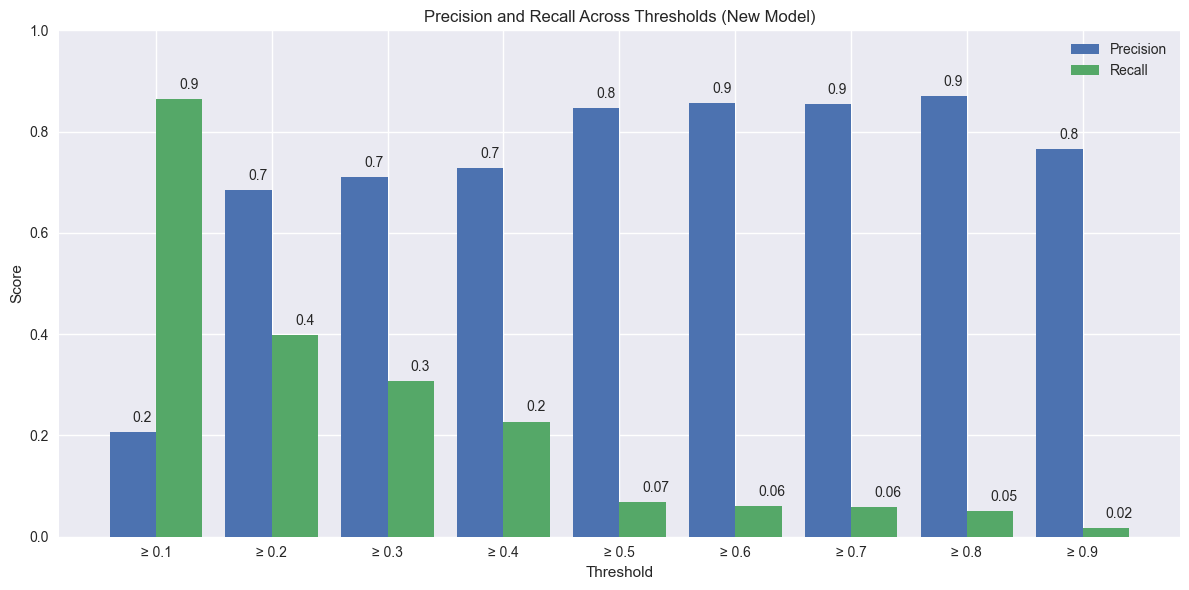

In [113]:
fig, ax = plt.subplots(figsize=(12, 6))

threshold = results['Threshold']
x = np.arange(len(threshold))
precision = results['Precision']
recall = results['recall']
width = 0.4
bars_precision = ax.bar(x - width/2, precision, width, label ='Precision')
bars_recall = ax.bar(x + width/2, recall, width, label = 'Recall')

ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision and Recall Across Thresholds (New Model)')
ax.set_xticks(x)
ax.set_xticklabels([f'≥ {t}' for t in threshold])
ax.legend()
ax.set_ylim(0, 1)

for bar in bars_precision:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.1}')
for bar in bars_recall:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.1}')

plt.legend()
plt.tight_layout()
plt.show()

In [108]:
rule_two_mask = df['newModelScore'] >= 0.2
rule_two = evaluate_rule(rule_two_mask, df['customerStatus'], 'New Model Score >= 0.2')
rule_two


{'Rule': 'New Model Score >= 0.2',
 'Blocked': 464,
 'Fraud Caught': 318,
 'Legitame Blocked': 146,
 'Percision': 68.53,
 'Recall': 39.75,
 'Block Rate': 4.3}

In [109]:
rule3_permissive

{'Rule': 'New model score threshold at 0.3',
 'Blocked': 346,
 'Fraud Caught': 246,
 'Legitame Blocked': 100,
 'Percision': 71.1,
 'Recall': 30.75,
 'Block Rate': 3.2}

In [114]:
rule3_at_4_mask = df['newModelScore'] >= 0.4
rule_3_at_4 = evaluate_rule(rule3_at_4_mask, df['customerStatus'], 'New Model Score ≥ 0.4')
rule_3_at_4

{'Rule': 'New Model Score ≥ 0.4',
 'Blocked': 250,
 'Fraud Caught': 182,
 'Legitame Blocked': 68,
 'Percision': 72.8,
 'Recall': 22.75,
 'Block Rate': 2.31}

## Rule 4: Combination

Here I combine Rules 1 and 3 using both an combined mask (Either one OR the other rule is triggered) and using a overlap mask (both rule must be triggerd)

In [46]:
combined_mask = (rule1_mask | rule3_permissive_mask)
combined_rule = evaluate_rule(combined_mask, df['customerStatus'], "Combined Rule 1 and Rule 3")
combined_rule

{'Rule': 'Combined Rule 1 and Rule 3',
 'Blocked': 744,
 'Fraud Caught': 432,
 'Legitame Blocked': 312,
 'Percision': 58.06,
 'Recall': 54.0,
 'Block Rate': 6.89}

In [47]:
overlap_mask = (rule1_mask & rule3_permissive_mask)
overlap_rule = evaluate_rule(overlap_mask, df['customerStatus'], "Overlap of Rule 1 and Rule 3")
overlap_rule

{'Rule': 'Overlap of Rule 1 and Rule 3',
 'Blocked': 201,
 'Fraud Caught': 186,
 'Legitame Blocked': 15,
 'Percision': 92.54,
 'Recall': 23.25,
 'Block Rate': 1.86}

### Evaluation

**Good Rule**

**The combination rule is the strongest performer overall, but the real insight is in the overlap.**

**Combined Rule (Rule 1 OR Rule 3):**

- Catches 432 fraudsters, the highest recall of any single rule at 54%, up from 46.5% for Rule 1 alone
- Only adds 145 additional blocks over Rule 1 alone (744 vs 599), gaining 60 more fraudsters caught
- Block rate rises modestly from 5.55% to 6.89%, a reasonable cost for the additional coverage

**The Overlap:**

- 201 orders triggered both rules simultaneously (googlepay AND newModelScore >= 0.3)
- Of those 201, 186 were confirmed fraudsters with **92.54% precision**
- When two independent signals agree, confidence in the block is near-certain

**Recommended tiered approach:**

Rather than applying a single blanket block, this suggests a two-tier strategy:

| Tier | Condition | Action | Precision |
|------|-----------|--------|-----------|
| Auto-block | Triggers both Rule 1 AND Rule 3 | Block immediately | 92.54% |
| Review queue | Triggers only one rule | Human review before decision | ~65% |

This gives the client maximum fraud coverage while minimising unnecessary friction for genuine customers. The auto-block tier is high confidence enough to act on programmatically; the review queue ensures borderline cases get a human decision rather than an automatic block.

In [48]:
results = [rule1, strict_rule, rule3_permissive, combined_rule, overlap_rule]
summary_df = pd.DataFrame(results)
summary_df

,Rule,Blocked,Fraud Caught,Legitame Blocked,Percision,Recall,Block Rate
0,Block Googlepay Transactions,599,372,227,62.10,46.50,5.55
1,Block Low - High Risk Markets,62,23,39,37.10,2.88,0.57
2,New model score threshold at 0.3,346,246,100,71.10,30.75,3.20
3,Combined Rule 1 and Rule 3,744,432,312,58.06,54.00,6.89
4,Overlap of Rule 1 and Rule 3,201,186,15,92.54,23.25,1.86


# Model Evaluation
---


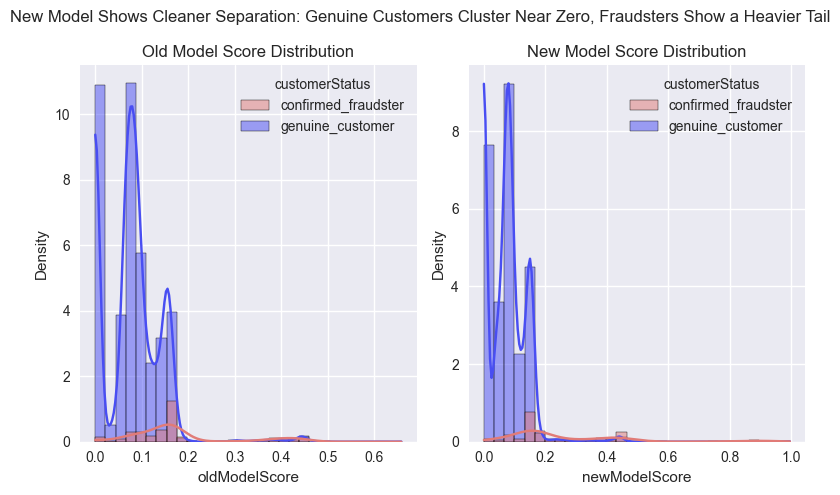

In [49]:
''' Score Distribution of models, grouped by customers '''

fig, axes = plt.subplots(1, 2, figsize=(8, 5))

sns.histplot(data=df, x='oldModelScore', bins=30, kde=True, hue='customerStatus', stat='density', ax=axes[0], palette={'confirmed_fraudster': '#E17B77', 'genuine_customer': '#494EF2'})
sns.histplot(data=df, x='newModelScore', bins=30, kde=True, hue='customerStatus', stat='density', ax=axes[1],palette={'confirmed_fraudster': '#E17B77', 'genuine_customer': '#494EF2'}) 

axes[0].set_title('Old Model Score Distribution')                                                                                                          
axes[1].set_title('New Model Score Distribution')
                                                                                                                                                            
fig.suptitle('New Model Shows Cleaner Separation: Genuine Customers Cluster Near Zero, Fraudsters Show a Heavier Tail')
plt.tight_layout()
plt.show()

The new model clusters genuine customer scores around 0 more than the old model, with the peak being narrower and higher. This shows that the new model is more decisive about clearing genuine customers, assigning them confidently low scores. 
The fraudster distribution in both models has a long flat tail, however, the new model's tail extends furhter up to ~1 whereas the old model stops at ~0.65. The new model is more confident about fraudsters

However, both models still have significant overlap between blue and green, meaning that a large portions of fraudsters are being given the same score as genuine customers, which is why relying soley on model scores for threshold based on these two models is difficult and requires general rules.

In [50]:
# Extract the y_pred as model scores from the data
y_pred_old_model = df['oldModelScore']
y_pred_new_model = df['newModelScore']
y_test = df['is_fraud']

# Calculate ROC-AUC for both models
old_model_fpr, old_model_tpr, old_model_thresholds = roc_curve(y_test, y_pred_old_model)
old_model_roc_auc = auc(old_model_fpr, old_model_tpr)

new_model_fpr, new_model_tpr, new_model_thresholds = roc_curve(y_test, y_pred_new_model)
new_model_roc_auc = auc(new_model_fpr, new_model_tpr)

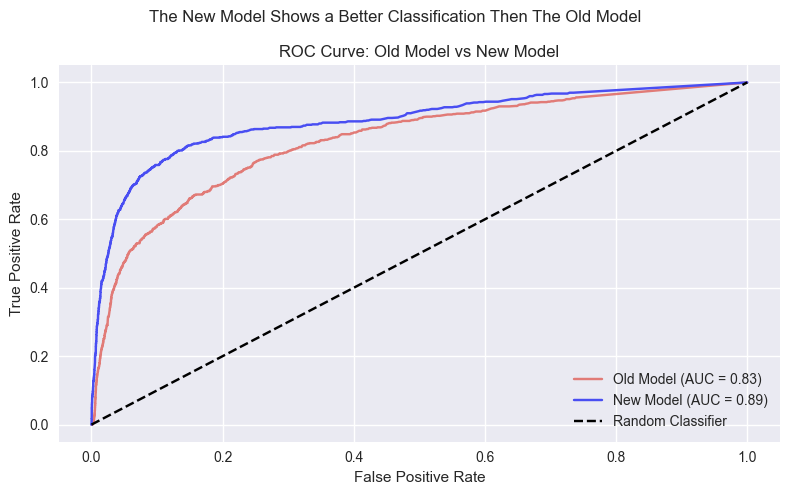

In [51]:
''' ROC-AUC Cruve comparision '''

fig, ax = plt.subplots(figsize=(8, 5))                                                                                                               

ax.plot(old_model_fpr, old_model_tpr, label=f'Old Model (AUC = {old_model_roc_auc:.2f})', color='#E17B77')                                                            
ax.plot(new_model_fpr, new_model_tpr, label=f'New Model (AUC = {new_model_roc_auc:.2f})', color='#494EF2')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Old Model vs New Model')
ax.legend()

fig.suptitle("The New Model Shows a Better Classification Then The Old Model")
plt.tight_layout()
plt.show()

The new model scores a higher AUC score with the 0.89 compared to 0.83, the curve for the new model is also clsoer to the gold standard TPR and is therefore better at distinguising fraudsters from genuine customers

In [52]:
# PR-AUC
old_model_precision, old_model_tpr, old_model_thresholds = precision_recall_curve(y_test, y_pred_old_model)
old_model_pr_auc = auc(old_model_tpr, old_model_precision)

new_model_precision, new_model_tpr, new_model_thresholds = precision_recall_curve(y_test, y_pred_new_model)
new_model_pr_auc = auc(new_model_tpr, new_model_precision)

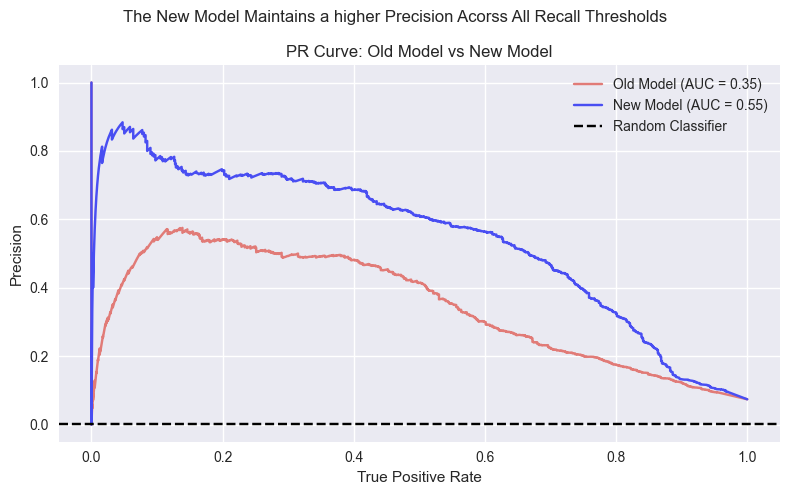

In [53]:
''' PR-AUC Comparison '''

fig, ax = plt.subplots(figsize=(8, 5))                                                                                                               

ax.plot(old_model_tpr, old_model_precision, label=f'Old Model (AUC = {old_model_pr_auc:.2f})', color='#E17B77')                                                            
ax.plot(new_model_tpr, new_model_precision, label=f'New Model (AUC = {new_model_pr_auc:.2f})', color='#494EF2')
ax.axhline(y=(overall_fraud_rate/100), color='k', label='Random Classifier', linestyle='--')

ax.set_xlabel('True Positive Rate')
ax.set_ylabel('Precision')
ax.set_title('PR Curve: Old Model vs New Model')
ax.legend()

fig.suptitle("The New Model Maintains a higher Precision Acorss All Recall Thresholds")
plt.tight_layout()
plt.show()

### Summary : Newer Model is better at identifying fraudulent transactions compared to the old Model

- From the score distributions we can see that the new model clusters genuine customers scores around 0, better than the old model and is more confident it's fraudulant classifications with a higher tail of fraud customers
- From the ROC-AUC curve we can see that the new model is better at balancing at catching fraud (TPR/Recall) while minimising false alarms (FPR) across all thresholds
- Additional metric : PR-AUC is a more rigorious metric for imbalanced datasets as it directly penalises false positives without a large TN pool
- The PR-AUC curve showed that the new model is more precise and catches more fraud overall

## Threshold Comparison


In [54]:
threshold_at_3_old_model_mask = y_pred_old_model >= 0.3
threshold_at_3_old_model = evaluate_rule(threshold_at_3_old_model_mask, df['customerStatus'], 'Old Model Threshold at 0.3')
threshold_at_3_old_model

{'Rule': 'Old Model Threshold at 0.3',
 'Blocked': 250,
 'Fraud Caught': 135,
 'Legitame Blocked': 115,
 'Percision': 54.0,
 'Recall': 16.88,
 'Block Rate': 2.31}

In [55]:
threshold_at_3_new_model_mask = y_pred_new_model >= 0.3
threshold_at_3_new_model = evaluate_rule(threshold_at_3_new_model_mask, df['customerStatus'], 'New Model Threshold at 0.3')
threshold_at_3_new_model

{'Rule': 'New Model Threshold at 0.3',
 'Blocked': 346,
 'Fraud Caught': 246,
 'Legitame Blocked': 100,
 'Percision': 71.1,
 'Recall': 30.75,
 'Block Rate': 3.2}

In [56]:
results = [threshold_at_3_old_model, threshold_at_3_new_model]
results_df = pd.DataFrame(results)
results_df

,Rule,Blocked,Fraud Caught,Legitame Blocked,Percision,Recall,Block Rate
0,Old Model Threshold at 0.3,250,135,115,54.0,16.88,2.31
1,New Model Threshold at 0.3,346,246,100,71.1,30.75,3.20


### Evaluation 

At the same threshold value of 0.3, the new model blocks 96 more transactions overal (346 vs 250), yet catches 111 more fraudsters (246 vs 135) while actually blocked 15 fewer legitimate customers (100 vs 115)

In relative terms the new model achieves a 32% improvement in precision and 82% improvement in recall at teh same operating thresholds

Cruicially, the new model cathes significantly more fraud while causing less disruption to genuine customers - this supports the conclusion from both the ROC-AUC and PR-AUC curves and makes a strong case for deployment